<a href="https://colab.research.google.com/github/FrankEHA/Datos/blob/master/loan_approval_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Aprobación de Préstamos

**Curso:** Ingeniería del Conocimiento (ISO56B)
**Dataset:** Loan Approval Prediction Dataset (Kaggle)


In [ ]:
# Paso 1: importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


In [ ]:
# Paso 2: descargar y cargar el dataset
import kagglehub
import os

path = kagglehub.dataset_download("architsharma01/loan-approval-prediction-dataset")
print("Archivos descargados en:", path)
print("Contenido:", os.listdir(path))

Using Colab cache for faster access to the 'loan-approval-prediction-dataset' dataset.
Archivos descargados en: /kaggle/input/loan-approval-prediction-dataset
Contenido: ['loan_approval_dataset.csv']


In [ ]:
# Paso 3: cargar el dataset con pandas
df = pd.read_csv(os.path.join(path, 'loan_approval_dataset.csv'))

# Limpiar espacios en nombres de columnas
df.columns = df.columns.str.strip()

print(f'Dataset cargado — {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado — 4269 registros, 13 columnas


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
# Paso 4: revisar calidad de los datos
df.info()
print('\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB

Valores nulos por columna:
lo

In [ ]:
print(df['loan_status'].unique())
print(df['education'].unique())
print(df['self_employed'].unique())

[' Approved' ' Rejected']
[' Graduate' ' Not Graduate']
[' No' ' Yes']


In [ ]:
# Paso 5: limpiar espacios y codificar variables categóricas
# Limpiar espacios en todas las columnas de texto
for col in ['education', 'self_employed', 'loan_status']:
    df[col] = df[col].str.strip()

# Verificar que quedó limpio
print(df['loan_status'].unique())
print(df['education'].unique())
print(df['self_employed'].unique())

# Codificar el target: Approved = 1, Rejected = 0
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

# Codificar education: Graduate = 1, Not Graduate = 0
df['education'] = df['education'].map({'Graduate': 1, 'Not Graduate': 0})

# Codificar self_employed: Yes = 1, No = 0
df['self_employed'] = df['self_employed'].map({'Yes': 1, 'No': 0})

# loan_id no aporta información predictiva, la eliminamos
df = df.drop(columns='loan_id')

print('\nTipos de datos después de la codificación:')
print(df.dtypes)
df.head()

['Approved' 'Rejected']
['Graduate' 'Not Graduate']
['No' 'Yes']

Tipos de datos después de la codificación:
no_of_dependents            int64
education                   int64
self_employed               int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                 int64
dtype: object


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


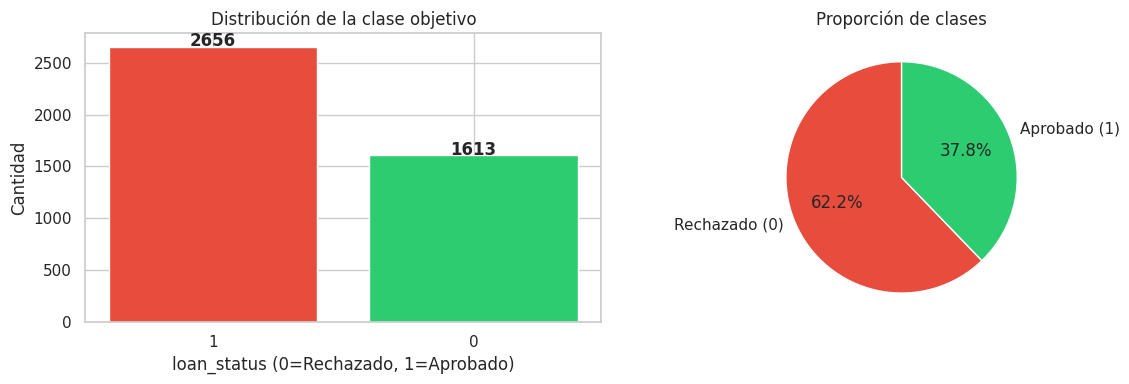

In [ ]:
# Paso 6: distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['loan_status'].value_counts()
axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('loan_status (0=Rechazado, 1=Aprobado)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['Rechazado (0)', 'Aprobado (1)'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

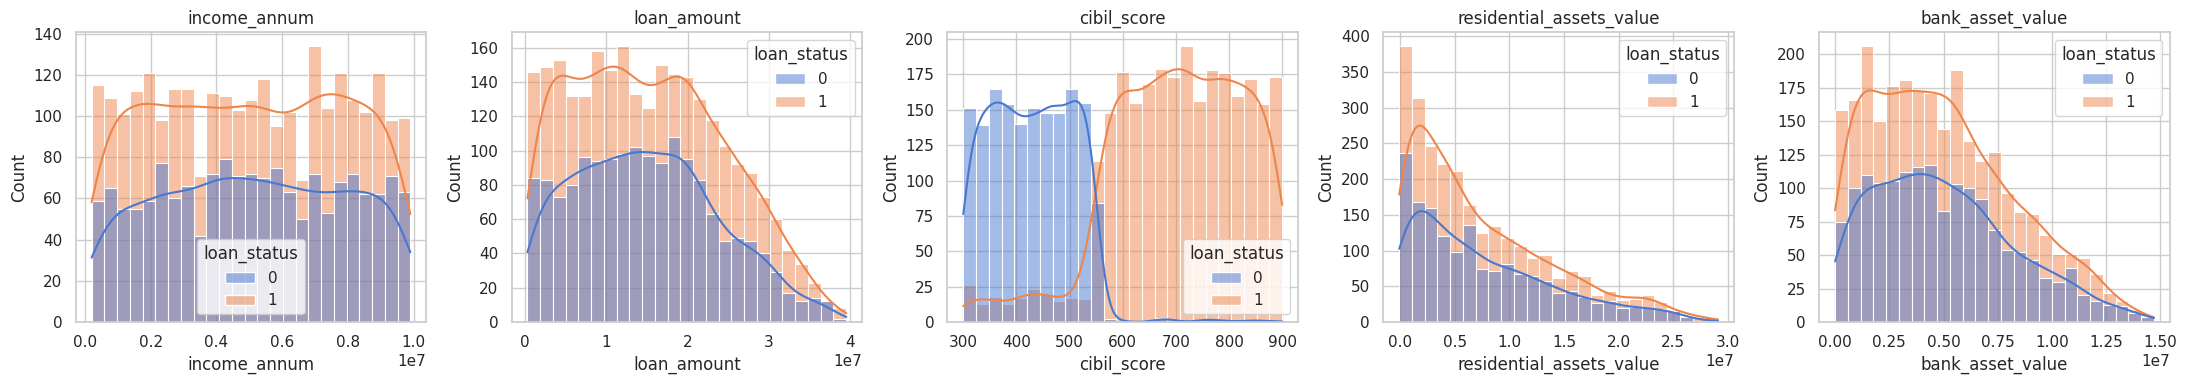

In [ ]:
# Distribución de variables numéricas clave
num_cols = ['income_annum', 'loan_amount', 'cibil_score', 'residential_assets_value', 'bank_asset_value']

fig, axes = plt.subplots(1, len(num_cols), figsize=(22, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='loan_status', kde=True, ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()

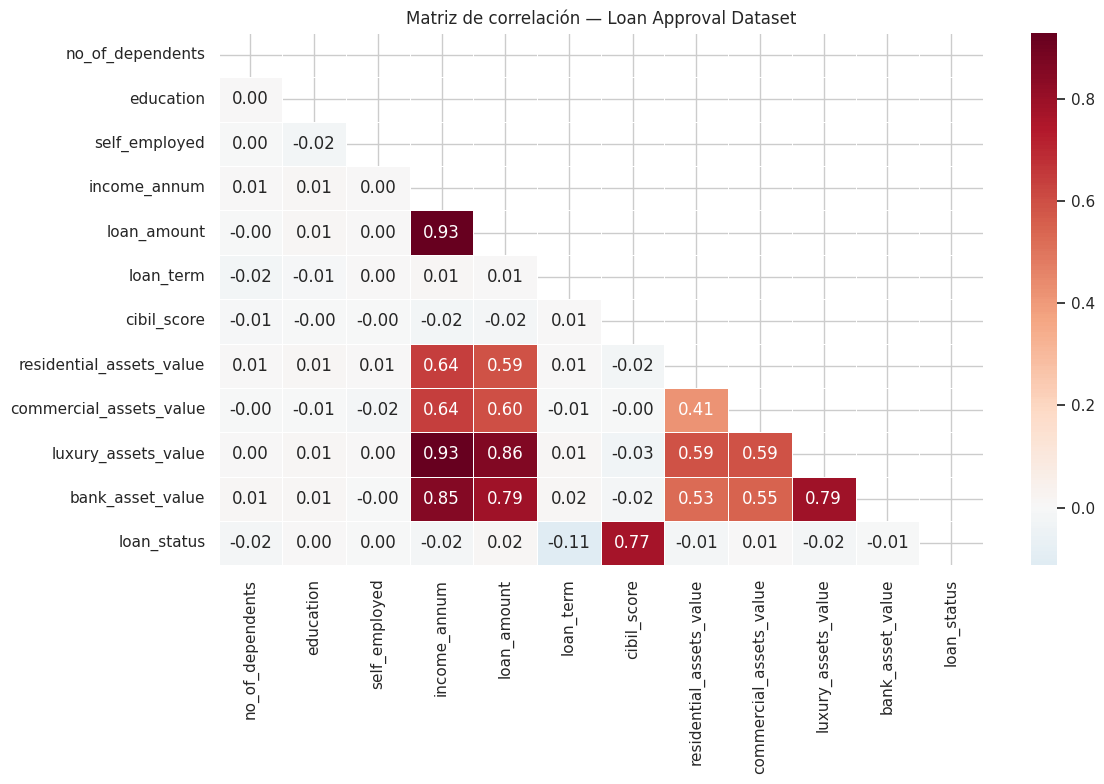

In [ ]:
# Paso 7: matriz de correlación
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Matriz de correlación — Loan Approval Dataset')
plt.tight_layout()
plt.show()

In [ ]:
# Paso 8: separar features y target
X = df.drop(columns='loan_status')
y = df['loan_status']

print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')

Features: (4269, 11)
Target:   (4269,)


In [ ]:
# Paso 9: split train/test (80-20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporción target en test:\n{y_test.value_counts(normalize=True).round(3)}')

Train: 3415 muestras
Test:  854 muestras

Proporción target en train:
loan_status
1    0.622
0    0.378
Name: proportion, dtype: float64

Proporción target en test:
loan_status
1    0.622
0    0.378
Name: proportion, dtype: float64


In [ ]:
# Paso 10: definir los pipelines
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

# Paso 11: entrenamiento y validación cruzada (5-fold)
results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

LogisticRegression         Accuracy CV: 0.9145 ± 0.0054
DecisionTree               Accuracy CV: 0.9643 ± 0.0090
RandomForest               Accuracy CV: 0.9701 ± 0.0062


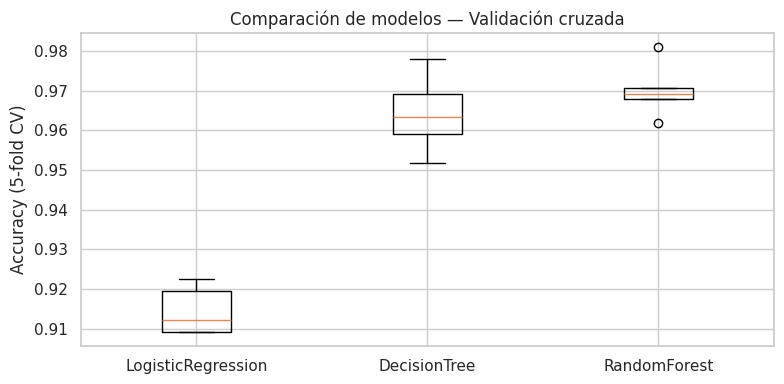

In [ ]:
# Paso 12: comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Validación cruzada')
plt.tight_layout()
plt.show()

In [ ]:
# Paso 13: seleccionar el mejor modelo y entrenarlo con todo el train set
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Rechazado', 'Aprobado']))

Mejor modelo: RandomForest
Accuracy en test: 0.9801

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Rechazado       0.98      0.97      0.97       323
    Aprobado       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



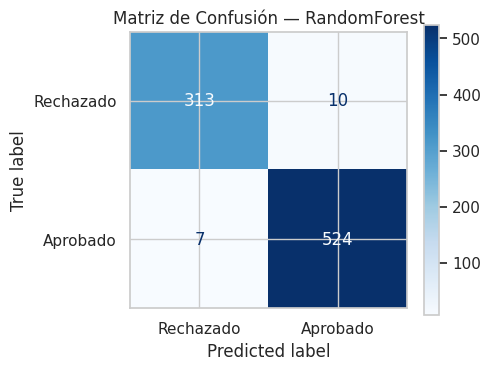

In [ ]:
# Paso 14: matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Rechazado', 'Aprobado'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

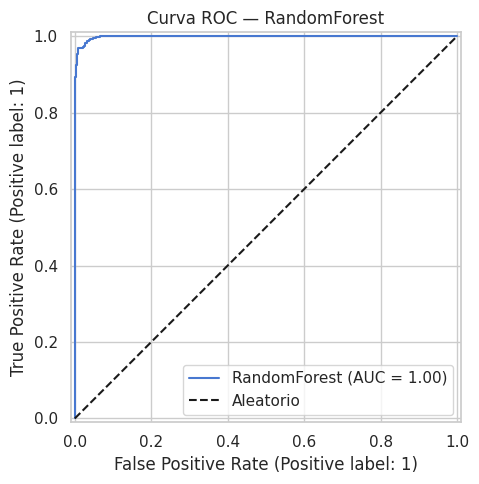

In [ ]:
# Paso 15: curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Paso 16: guardar el modelo
MODEL_PATH = 'loan_approval_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

Modelo guardado en: loan_approval_model.joblib


In [ ]:
# Paso 17: cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


In [ ]:
# Paso 18: función de inferencia (simula un endpoint de predicción)
def predict_loan_approval(applicant_data: dict) -> dict:
    """
    Recibe un diccionario con los datos del solicitante
    y retorna la predicción y la probabilidad.
    """
    model = joblib.load(MODEL_PATH)

    input_df = pd.DataFrame([applicant_data])[X.columns]

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]

    prediction_label = 'Aprobado' if pred == 1 else 'Rechazado'

    return {
        'prediccion': prediction_label,
        'probabilidad_aprobado': round(float(proba[1]), 4),
        'probabilidad_rechazado': round(float(proba[0]), 4)
    }

# Ejemplo de uso con un solicitante ficticio
solicitante_ejemplo = {
    'no_of_dependents': 2, 'education': 1, 'self_employed': 0,
    'income_annum': 9000000, 'loan_amount': 25000000, 'loan_term': 12,
    'cibil_score': 750, 'residential_assets_value': 5000000,
    'commercial_assets_value': 3000000, 'luxury_assets_value': 15000000,
    'bank_asset_value': 6000000
}

resultado = predict_loan_approval(solicitante_ejemplo)
print('\n--- Resultado de inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')


--- Resultado de inferencia ---
  prediccion: Aprobado
  probabilidad_aprobado: 0.9599
  probabilidad_rechazado: 0.0401


## Conclusiones

**Dataset:** Loan Approval Prediction Dataset (Kaggle, architsharma01) — 4269 registros, 12 features numéricas tras la codificación de `education`, `self_employed` y `loan_status`.

**Mejor modelo:** RandomForest, seleccionado por accuracy en validación cruzada (0.9701 ± 0.0062), con un accuracy en test de **98.01%**, precision y recall balanceados entre ambas clases (0.97–0.99).

**Observación clave:** la matriz de correlación mostró que `cibil_score` (puntaje crediticio) tiene una correlación de 0.77 con `loan_status`, muy por encima del resto de las variables — es, por lejos, el factor más determinante en la aprobación del préstamo en este dataset. Este dominio de una sola variable, junto con el accuracy tan alto obtenido, sugiere que los datos podrían haber sido generados siguiendo una regla simplificada de aprobación, en lugar de reflejar historial real de decisiones bancarias.

**Despliegue:** el modelo fue serializado con `joblib` y verificado, incluyendo una función de inferencia (`predict_loan_approval`) que recibe los datos de un solicitante y retorna la predicción junto con la probabilidad asociada.